In [5]:
import numpy as np
import matplotlib.pyplot as plt
from information_measures import binned_h, kolchinsky_h
import os

In [6]:
FOLDER = 'MNIST_128_64_32'

In [7]:
data = None
layers = {}

for file in os.listdir(FOLDER):
    if 'data' in file:
        data = np.load(os.path.join(FOLDER, file))
    else:
        layer_name = file.removesuffix('.npz')
        layer_data = np.load(os.path.join(FOLDER, file))
        layers[int(layer_name)] = [epoch for epoch in layer_data.values()]

In [30]:
MI_HX = {}
MI_HY = {}

Y_labels = data['true_labels']

for key in layers.keys():
    print(f'Analyzing {key} neurons layer')
    layer = layers[key]
    epochs = len(layer)
    MI_HX[key], MI_HY[key] = [], []

    for epoch, epoch_layer in enumerate(layer):
        print(f'Computing mutual information for {key}-neuron layer, epoch {epoch+1}/{epochs}')
        mi_hx, mi_hy = binned_h(epoch_layer, Y_labels, bins=100)
        MI_HX[key].append(mi_hx)
        MI_HY[key].append(mi_hy)

    MI_HX[key] = np.array(MI_HX[key])
    MI_HY[key] = np.array(MI_HY[key])

Analyzing 64 neurons layer
Computing mutual information for 64-neuron layer, epoch 1/100
Computing mutual information for 64-neuron layer, epoch 2/100
Computing mutual information for 64-neuron layer, epoch 3/100
Computing mutual information for 64-neuron layer, epoch 4/100
Computing mutual information for 64-neuron layer, epoch 5/100
Computing mutual information for 64-neuron layer, epoch 6/100
Computing mutual information for 64-neuron layer, epoch 7/100
Computing mutual information for 64-neuron layer, epoch 8/100
Computing mutual information for 64-neuron layer, epoch 9/100
Computing mutual information for 64-neuron layer, epoch 10/100
Computing mutual information for 64-neuron layer, epoch 11/100
Computing mutual information for 64-neuron layer, epoch 12/100
Computing mutual information for 64-neuron layer, epoch 13/100
Computing mutual information for 64-neuron layer, epoch 14/100
Computing mutual information for 64-neuron layer, epoch 15/100
Computing mutual information for 64-n

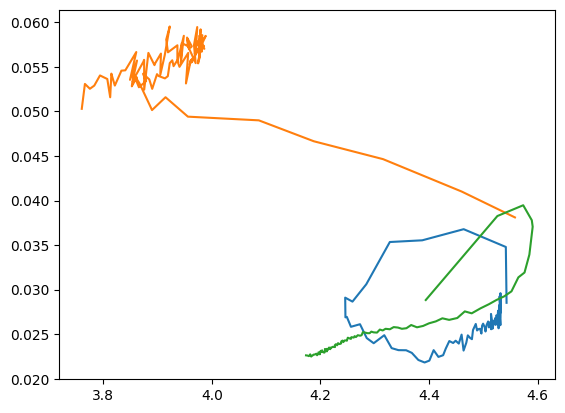

In [36]:
fig, ax = plt.subplots(1,1)
for key in layers.keys():
    ax.plot(MI_HX[key], MI_HY[key])

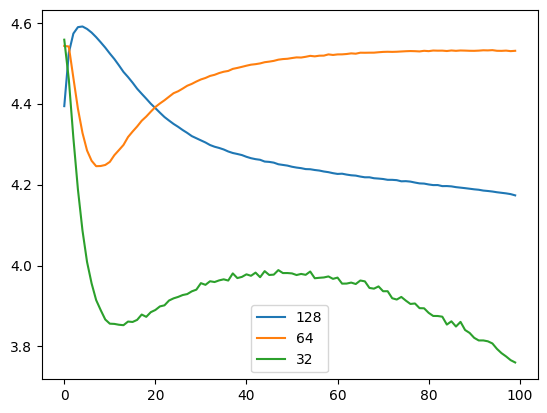

In [34]:
for key in [128, 64, 32]:
    plt.plot(MI_HX[key], label=f'{key}')
plt.legend()

In [35]:
layers[128][99]

array([[-0.75637758, -0.87524951, -0.994003  , ..., -0.7641781 ,
         0.29113305, -0.08294079],
       [ 0.58484787,  0.73980474, -0.30714384, ..., -0.90333366,
         0.98383409,  0.37085792],
       [ 0.54445392,  0.19956081,  0.66903168, ..., -0.132816  ,
        -0.71225649,  0.65357178],
       ...,
       [-0.30380052, -0.95648032, -0.43593219, ..., -0.98150325,
        -0.91195053,  0.83046633],
       [ 0.33692712, -0.98141229,  0.8760227 , ..., -0.99414086,
        -0.54974949,  0.20395435],
       [ 0.57339263, -0.92362446,  0.47323623, ..., -0.99988741,
         0.9938373 ,  0.75154722]], shape=(10000, 128))